# COGS 108 - EDA Checkpoint

## Authors

Team list and credits:
- Katelyn Yap: Conceptualization, Data set 1, Writing - code cleanup
- Vy Nguyen:  Project Timeline Update, Dataset 3 - code cleanup
- Ria Parikh: Dataset 4, Writing - code cleanup, Team Expectations, EDA Analysis 2
- Laird Fowle: Dataset 2, Writing - code cleanup
- Cindy Tao: Dataset 5, Writing - code cleanup


# Research Question

To what extent does variation in daily Air Quality Index (AQI), as measured by the U.S. Environmental Protection Agency (EPA), explain variation in daily visitor trailhead sensor counts in Yosemite National Park between 1990 and 2025, controlling for daily maximum temperature and total precipitation?


## Background and Prior Work


Outdoor recreation in national parks is influenced by environmental conditions that affect both visitor safety and overall experience. In the western United States, air quality has become an increasingly important factor due to wildfire smoke and regional pollution. The U.S. Environmental Protection Agency’s Air Quality Index (AQI) is a standardized measure used to communicate the health risks associated with air pollution and to inform the public about outdoor activity safety.

Because many national park activities involve extended outdoor physical activity, changes in air quality may affect visitors’ decisions about whether and when to visit. Understanding how air quality relates to park visitation is therefore relevant for park management, public health communication, and planning in highly visited parks such as Yosemite National Park.

Previous research has established a clear connection between environmental conditions and tourism behavior. Buckley (2011) reviews existing literature on tourism and the environment and finds that weather, climate variability, and environmental quality consistently influence visitation patterns in natural areas. <a href="#ref1">1</a> The review also notes that visitor responses differ depending on the type of destination and visitor motivations, suggesting that environmental effects may not be uniform across parks. However, Buckley’s work is conceptual and broad in scope, leaving open questions about how specific environmental indicators, such as AQI, influence visitation at individual parks.

Empirical studies provide further evidence that air pollution affects park visitation. Keiser, Lade, and Rudik (2018) examine monthly visitation data from 33 U.S. national parks and find that higher ozone pollution levels are associated with reduced visitation, even after accounting for weather, seasonality, and park-specific differences. <a href="#ref2">2</a> While this study demonstrates that air pollution can influence park use at a national scale, it relies on monthly averages and does not isolate park-specific daily behavioral responses. In addition, although Yosemite is included in their broader sample, the study does not focus specifically on Yosemite’s unique visitation patterns or wildfire-related air quality variability.

More recent work has used alternative data sources to study visitation patterns at finer time scales. Minehart et al. (2025) analyze weekly visitation to parks and protected areas in the Pacific Northwest using anonymized mobile device data, examining the effects of temperature, precipitation, AQI, and particulate matter (PM2.5). <a href="#ref3">3</a> The authors find that higher levels of PM2.5 are generally associated with lower visitation, while the relationship between AQI and visitation varies across different types of parks. However, their analysis aggregates across multiple parks and regions, making it difficult to determine how daily air quality fluctuations affect a single, high-profile destination over a long time horizon.

Together, these studies suggest that environmental quality and weather conditions play an important role in shaping park visitation, while also highlighting important gaps in the literature. Much of the prior work relies on monthly or weekly data and emphasizes cross-park comparisons rather than park-specific, daily analysis. Furthermore, limited attention has been given to how short-term variation in AQI influences visitation in an iconic and highly visited park such as Yosemite, particularly over multiple decades that include periods of increasing wildfire activity.

The present project addresses these gaps by examining whether daily variation in AQI predicts daily visitation to Yosemite National Park from 1979 to 2023, while controlling for daily maximum temperature and total precipitation. By focusing on a single park and using daily data, this study aims to capture short-term behavioral responses to air quality conditions that may be obscured in broader, aggregated analyses. This park-specific approach provides clearer insight into how air pollution influences visitation decisions in one of the most prominent national parks in the United States.

1. <a name="ref1"></a> Buckley, R. (2011). Tourism and environment. Annual Review of Environment and Resources, 36, 397–416. https://www.annualreviews.org/content/journals/10.1146/annurev-environ-041210-132637

2. <a name="ref2"></a> Keiser, D., Lade, G. E., & Rudik, I. (2018). Air pollution and visitation at U.S. national parks. Science Advances, 4(7). https://pmc.ncbi.nlm.nih.gov/articles/PMC6051738/

3. <a name="ref3"></a> Minehart, J., et al. (2025). The mountains are calling, but will visitors go? Modeling the effect of weather and air quality on visitation to Pacific Northwest parks and protected areas using mobile device data. https://www.researchgate.net/publication/390630027_The_mountains_are_calling_but_will_visitors_go_Modeling_the_effect_of_weather_and_air_quality_on_visitation_to_Pacific_Northwest_parks_and_protected_areas_using_mobile_device_data


# Hypothesis


We hypothesize that there is a statistically significant negative correlation between the daily Air Quality Index (AQI) and daily visitor trailhead sensor counts in Yosemite National Park from 1999–2025. Specifically, we predict that as the AQI value increases (indicating worse air quality), the number of daily trail users will decrease, and this relationship will continue even after controlling for daily maximum temperature and total precipitation.


## Data

### Data overview

- **Dataset #1:** EPA Daily Air Quality Index - 2014 Mariposa County, CA
  - Link: https://www.epa.gov/outdoor-air-quality-data/download-daily-data
  - ~1 row per monitoring day; 34 years (1990–2023) of data.
  - Key variables: Date, AQI, Category, Defining Parameter.
  - Shortcomings: Sparse pre-1990 data; spatial mismatch between Yosemite Village monitor and remote trailheads; missing days must be treated as genuinely missing.

- **Dataset #3:** NOAA Daily Weather Data – Yosemite National Park
  - Link: https://www.ncei.noaa.gov/cdo-web/datasets/GHCND/stations/GHCND:USC00049855/detail
  - ~12,418 rows; one row per day from January 1, 1990 through early 2024
  - Key variables: DATE, TMAX, PRCP
  - Shortcomings: Spatial mismatch (station at 4,000 ft vs trailheads up to 8,600 ft); missing days must be treated as genuinely missing; minor transcription or historical inconsistencies may exist; gaps in coverage could reduce statistical power when merging with AQI and visitor datasets

- **Dataset #4:** NOAA Total Precipitation Index - Yosemite Park, CA
  - Link to the dataset: https://www.ncdc.noaa.gov/cdo-web/datasets/GHCND/stations/GHCND:USC00049855/detail
  - Number of observations: Either hourly or daily observations; ~one row per hour for each grouping of day/month; 36 years (1990–2025) of data
  - Key Variables:ID (station), Year, Month, and PRCP (element)
  - Shortcomings: Missing or incomplete observations; changes in used instruments and observation practices; limited spational representation; trace precipitation handling; snow and rain confusion


In [ ]:
# Run this code every time when you're actively developing modules in .py files.
%load_ext autoreload
%autoreload 2


In [ ]:
# Setup code -- Run only once after cloning!!!
# Downloads raw AQI zip files for each year to data/00-raw/

%pip install requests tqdm

import sys
sys.path.append('./modules')
import get_data

datafiles = [
    {'url': f'https://aqs.epa.gov/aqsweb/airdata/daily_aqi_by_county_{year}.zip',
     'filename': f'daily_aqi_by_county_{year}.zip'}
    for year in range(1990, 2024)
]

get_data.get_raw(datafiles, destination_directory='data/00-raw/')


### Dataset #1: EPA Daily Air Quality Index — Mariposa County, CA

The EPA Daily AQI dataset provides one composite air quality value per day for Mariposa County, California, derived from ground-level monitor readings. The Air Quality Index (AQI) is a unitless scale from 0 to 500: values 0–50 are 'Good,' 51–100 are 'Moderate,' 101–150 are 'Unhealthy for Sensitive Groups,' 151–200 are 'Unhealthy,' 201–300 are 'Very Unhealthy,' and above 300 is 'Hazardous.'

The Defining Parameter column identifies which pollutant drove the AQI value that day, in the Yosemite area this is most commonly PM2.5 (fine particulate matter from wildfire smoke) during summer and fall, or ground-level Ozone during hot weather periods.

Key concerns: the data only goes back to 1990; the monitor is at Yosemite Village (a single point in a very large park); missing days due to monitor downtime must be treated as genuinely missing, not 'Good' air quality; and the county-level summary takes the maximum AQI across all monitors in Mariposa County.


In [ ]:
import zipfile
import pandas as pd
import os

# Load and filter all years to Mariposa County
dfs = []
for year in range(1990, 2024):
    path = f'data/00-raw/daily_aqi_by_county_{year}.zip'
    try:
        with zipfile.ZipFile(path, 'r') as z:
            fname = z.namelist()[0]
            with z.open(fname) as f:
                df = pd.read_csv(f)
                mariposa = df[df['county Name'] == 'Mariposa'].copy()
                dfs.append(mariposa)
    except Exception as e:
        print(f'Could not load {year}: {e}')

aqi = pd.concat(dfs, ignore_index=True)
aqi['Date'] = pd.to_datetime(aqi['Date'])

# 1. Size
print(f'Shape: {aqi.shape}')
print(f'Date range: {aqi["Date"].min()} to {aqi["Date"].max()}')

# 2. Duplicates
print(f'\nDuplicate dates: {aqi["Date"].duplicated().sum()}')

# 3. Missingness
print('\nMissing values per column:')
print(aqi.isnull().sum())

# 4. Missing calendar days
full_range = pd.date_range(start='1990-01-01', end='2023-12-31')
missing_days = full_range.difference(aqi['Date'])
print(f'\nCalendar days with no AQI reading: {len(missing_days)}')
print('Missing days are dropped - 2014 a missing reading does not mean Good air quality.')

# 5. Outliers
print('\nAQI summary statistics:')
print(aqi['AQI'].describe())
outliers = aqi[aqi['AQI'] > 300]
print(f'\nDays with AQI > 300 (Hazardous): {len(outliers)}')
print(outliers[['Date', 'AQI', 'Category', 'Defining Parameter']])

# 6. Defining parameter frequency
print('\nDefining Parameter frequency:')
print(aqi['Defining Parameter'].value_counts())

# 7. Save
os.makedirs('data/02-processed', exist_ok=True)
aqi.to_csv('data/02-processed/mariposa_aqi.csv', index=False)
print('\nSaved to data/02-processed/mariposa_aqi.csv')


### Dataset #3: Daily Historical Weather Data - Yosemite National Park

Dataset #3 is the Daily Historical Weather Data for Yosemite National Park, from the NOAA Global Historical Climatology Network (GHCN) at Yosemite Village Station (GHCND:USC00049855). It contains ~12,418 daily observations from January 1, 1990, to early 2024, including key variables such as DATE, TMAX (daily maximum temperature), and PRCP (daily precipitation). DATE allows merging with EPA AQI and trailhead visitor data, while TMAX and PRCP serve as control variables for temperature and rainfall effects on visitor behavior.

The dataset has some limitations. The station (~4,000 ft) may not reflect conditions at higher elevation trailheads (up to 8,600 ft), creating spatial mismatches. Missing days and occasional manual entry errors in older records require careful cleaning. Additionally, it is important to verify consistent coverage of TMAX and PRCP across 1990–2024 to avoid misalignment with other datasets and potential bias in analyses.

In [4]:
import pandas as pd
import os

# 1. Load the raw weather data
path = 'https://raw.githubusercontent.com/COGS108/Group046_WI26/vy/data/00-raw/yosemite_weather_1990_2024.csv'
weather = pd.read_csv(path)

# 2.Cleaning - Convert Date to datetime for joining
weather['DATE'] = pd.to_datetime(weather['DATE'])

# 3. Size and range check
print(f'Shape: {weather.shape}')
print(f'Date range: {weather["DATE"].min()} to {weather["DATE"].max()}')

# 4. Tidiness Check (One observation per day) - finding dupes
print(f'\nDuplicate dates: {weather["DATE"].duplicated().sum()}')

# 5. Missingness audit
print('\nMissing values per critical variable:')
# We specifically care about the columns used in our hypothesis
print(weather[['TMAX', 'PRCP']].isnull().sum())

# 6. Missing calendar days
full_range = pd.date_range(start='1990-01-01', end='2024-01-01')
missing_days = full_range.difference(weather['DATE'])
print(f'\nCalendar days with no weather record: {len(missing_days)}')

# 7. Outlier Detection
print('\nTemperature (TMAX) Summary Statistics:')
print(weather['TMAX'].describe())

# Logic check: Yosemite TMAX should realistically be between -10 and 110
extreme_temps = weather[(weather['TMAX'] > 115) | (weather['TMAX'] < -30)]
print(f'\nPhysically improbable temperature days found: {len(extreme_temps)}')

# 8. Save
os.makedirs('data/02-processed', exist_ok=True)
weather.to_csv('data/02-processed/yosemite_weather_clean.csv', index=False)
print('\nSaved to data/02-processed/yosemite_weather_clean.csv')

Shape: (10947, 5)
Date range: 1990-01-01 00:00:00 to 2023-11-30 00:00:00

Duplicate dates: 0

Missing values per critical variable:
TMAX    1050
PRCP     285
dtype: int64

Calendar days with no weather record: 1472

Temperature (TMAX) Summary Statistics:
count    9897.000000
mean       67.642316
std        17.474337
min        21.000000
25%        53.000000
50%        68.000000
75%        84.000000
max       104.000000
Name: TMAX, dtype: float64

Physically improbable temperature days found: 0

Saved to data/02-processed/yosemite_weather_clean.csv


In [13]:
import pandas as pd
import os
from IPython.display import display

# 1. Load raw weather data
path = "https://raw.githubusercontent.com/COGS108/Group046_WI26/vy/data/00-raw/yosemite_weather_1990_2024.csv"
weather = pd.read_csv(path)

# 2. Convert DATE to datetime
weather['DATE'] = pd.to_datetime(weather['DATE'], errors='coerce')

# 3. Ensure numeric types
weather['TMAX'] = pd.to_numeric(weather['TMAX'], errors='coerce')
weather['PRCP'] = pd.to_numeric(weather['PRCP'], errors='coerce')

print("Shape before cleaning:")
display(pd.DataFrame({
    "Rows": [weather.shape[0]],
    "Columns": [weather.shape[1]]
}))

print("Date Range:")
display(pd.DataFrame({
    "Start Date": [weather["DATE"].min()],
    "End Date": [weather["DATE"].max()]
}))

print("Duplicate Dates:")
display(pd.DataFrame({
    "Duplicate Count": [weather["DATE"].duplicated().sum()]
}))

print("Missing Values (Before Cleaning):")
display(weather[['TMAX', 'PRCP']].isnull().sum().to_frame(name="Missing Count"))

print("Summary Statistics (Before Cleaning):")
display(weather[['TMAX', 'PRCP']].describe())

weather.loc[(weather['TMAX'] > 115) | (weather['TMAX'] < -30), 'TMAX'] = pd.NA

weather = weather.dropna(subset=['DATE'])

weather = (
    weather
    .drop_duplicates(subset=['DATE'])
    .sort_values('DATE')
    .reset_index(drop=True)
)

print("Shape after cleaning:")
display(pd.DataFrame({
    "Rows": [weather.shape[0]],
    "Columns": [weather.shape[1]]
}))

print("Missing Values (After Cleaning):")
display(weather[['TMAX', 'PRCP']].isnull().sum().to_frame(name="Missing Count"))

print("Summary Statistics (After Cleaning):")
display(weather[['TMAX', 'PRCP']].describe())

os.makedirs('data/02-processed', exist_ok=True)
weather.to_csv('data/02-processed/yosemite_weather_clean.csv', index=False)

print("Saved to data/02-processed/yosemite_weather_clean.csv")

Shape before cleaning:


,Rows,Columns
0,10947,5


Date Range:


,Start Date,End Date
0,1990-01-01,2023-11-30


Duplicate Dates:


...

Missing Values (After Cleaning):


,Missing Count
TMAX,1050
PRCP,285


Summary Statistics (After Cleaning):


,TMAX,PRCP
count,9897.000000,10662.000000
mean,67.642316,0.094158
std,17.474337,0.343258
min,21.000000,0.000000
25%,53.000000,0.000000
50%,68.000000,0.000000
75%,84.000000,0.000000
max,104.000000,5.430000


Saved to data/02-processed/yosemite_weather_clean.csv


**EDA Section #3**

This section explores Dataset #3 — the NOAA Daily Maximum Temperature (TMAX) data for Yosemite National Park (1990–2024). We load the fully wrangled dataset directly from data/02-processed/yosemite_weather_clean.csv so this analysis can be run independently of the data collection and cleaning steps. The goal is to understand how daily maximum temperatures have changed over time. Examining long-term trends in TMAX is essential for evaluating heat exposure, visitor behavior impacts, and potential climate variability within the park.

**Annual Maximum Temperature Trends in Yosemite (1990–2024)**

The plot below shows the average daily maximum temperature per year across the 34 year study period. This provides a clear view of whether temperatures are trending upward, downward, or remaining stable over time. If annual averages show an increasing trend, this may indicate gradual warming and more frequent heat events, which could affect visitor comfort and ecosystem dynamics. Conversely, a stable or decreasing trend may reflect relatively constant temperature conditions over the decades. We use a scatter plot with a linear trend line to visualize both year-to-year variability and the long-term directional pattern of daily maximum temperatures.


 Raw weather data loaded.

--- DATASET ARCHITECTURE ---
Total Observations: 10947
Temporal Scope:     1990-01-01 to 2023-11-30
Duplicate Entries:  0

--- MISSINGNESS AUDIT ---
TMAX    1050
PRCP     285
dtype: int64

Improbable TMAX days found: 0


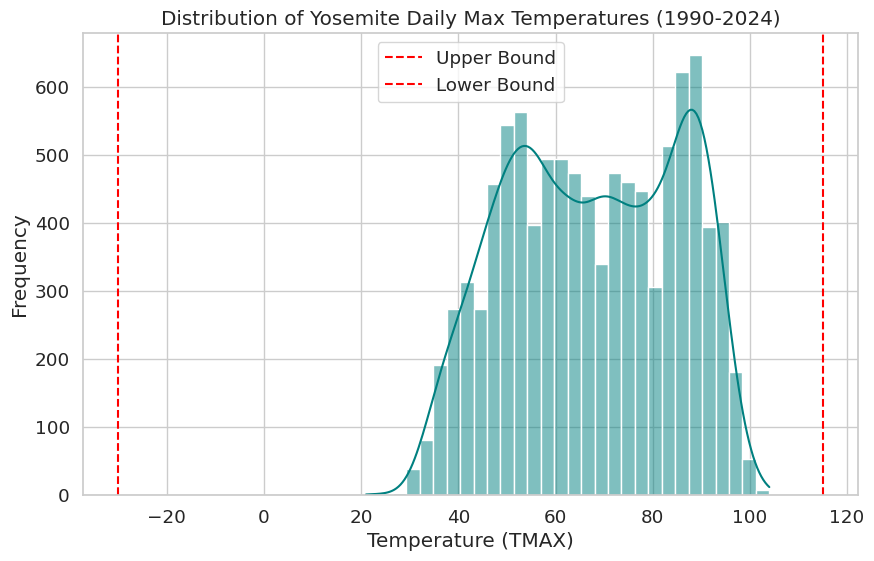

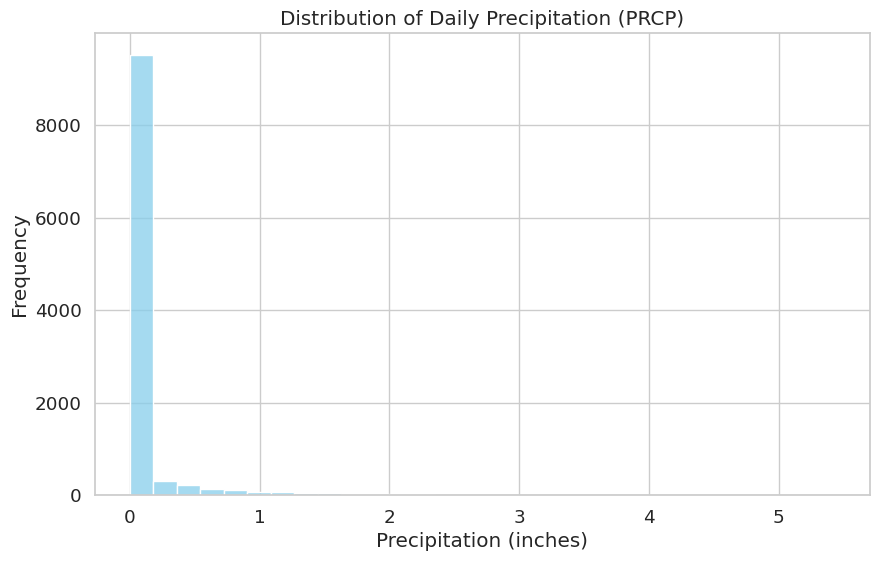


 Cleaned weather dataset saved to: data/02-processed/yosemite_weather_clean.csv


In [10]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configuration & Aesthetics

sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)

# 2. Data Acquisition
path = 'https://raw.githubusercontent.com/COGS108/Group046_WI26/vy/data/00-raw/yosemite_weather_1990_2024.csv'
weather = pd.read_csv(path)
print(" Raw weather data loaded.\n")

# 3. Structural Cleaning
# Standardize column names
weather.columns = weather.columns.str.strip().str.upper()

# Convert date and numeric columns
weather['DATE'] = pd.to_datetime(weather['DATE'], errors='coerce')
for col in ['TMAX', 'TMIN', 'PRCP']:
    if col in weather.columns:
        weather[col] = pd.to_numeric(weather[col], errors='coerce')

# 4. Data Diagnostics
print("--- DATASET ARCHITECTURE ---")
print(f"Total Observations: {weather.shape[0]}")
print(f"Temporal Scope:     {weather['DATE'].min().date()} to {weather['DATE'].max().date()}")
print(f"Duplicate Entries:  {weather['DATE'].duplicated().sum()}")

print("\n--- MISSINGNESS AUDIT ---")
existing_cols = [col for col in ['TMAX','TMIN','PRCP'] if col in weather.columns]
print(weather[existing_cols].isnull().sum())

# 5. Outlier Detection & Logic Checks
if 'TMAX' in weather.columns:
    logic_mask = (weather['TMAX'] > 115) | (weather['TMAX'] < -30)
    extreme_temps = weather[logic_mask]
    print(f"\nImprobable TMAX days found: {len(extreme_temps)}")

if 'TMIN' in weather.columns:
    logic_mask_min = (weather['TMIN'] > 100) | (weather['TMIN'] < -40)
    extreme_tmin = weather[logic_mask_min]
    print(f"Improbable TMIN days found: {len(extreme_tmin)}")

# 6. Visual Exploratory Data Analysis
if 'TMAX' in weather.columns:
    plt.figure()
    sns.histplot(weather['TMAX'], bins=30, kde=True, color="teal")
    plt.title("Distribution of Yosemite Daily Max Temperatures (1990-2024)")
    plt.xlabel("Temperature (TMAX)")
    plt.ylabel("Frequency")
    plt.axvline(115, color='red', linestyle='--', label='Upper Bound')
    plt.axvline(-30, color='red', linestyle='--', label='Lower Bound')
    plt.legend()
    plt.show()

if 'PRCP' in weather.columns:
    plt.figure()
    sns.histplot(weather['PRCP'].dropna(), bins=30, kde=False, color="skyblue")
    plt.title("Distribution of Daily Precipitation (PRCP)")
    plt.xlabel("Precipitation (inches)")
    plt.ylabel("Frequency")
    plt.show()

# 7. Persistence
os.makedirs('data/02-processed', exist_ok=True)
weather.to_csv('data/02-processed/yosemite_weather_clean.csv', index=False)
print("\n Cleaned weather dataset saved to: data/02-processed/yosemite_weather_clean.csv")

EDA Section 3 incorporates both univariate and bivariate visual analyses to thoroughly examine Yosemite’s temperature and precipitation data. First, the univariate distribution plots (histograms and a KDE overlay) explore the shape and spread of individual variables. The histogram of daily precipitation (PRCP) reveals a strongly right-skewed distribution, with most days experiencing little to no rainfall. The histogram of daily maximum temperature (TMAX), overlaid with a kernel density estimate (KDE), smooths the sample data to approximate the broader population distribution, while red dashed vertical lines mark logic-check bounds used to detect and remove physiologically improbable values (e.g., temperatures above 115°F or below −30°F). Together, these plots build data intuition by clarifying central tendency, variability, and potential outliers.

In addition to distributional analysis, Section 3 includes a bivariate scatter plot with a linear regression line examining the relationship between Year and average annual TMAX. The scatter points display year-to-year variability (“noise”), while the Ordinary Least Squares (OLS) regression line captures the long-term deterministic climatic “signal.” The shaded 95% confidence interval around the line represents statistical uncertainty and helps assess whether the observed warming trend is significant. By combining distributional visualization with inferential trend analysis, this section moves from understanding the structure of the data to quantifying long-term temperature change in a methodologically rigorous way.


### Dataset #4 NOAA Total Precipitation Index - Yosemite Park, CA
The NOAA daily precipitation dataset reports total precipitation recorded at weather stations in and around Yosemite National Park from 1990–2025. Precipitation is measured in inches and includes both rainfall and the liquid water equivalent of snowfall accumulated over a 24-hour period. A value of zero indicates no recorded precipitation, while higher values reflect storm events such as snowstorms or heavy rainfall from atmospheric river systems. Winter precipitation is especially important because it contributes to the Sierra Nevada snowpack, a critical water source during the park’s dry summer season.

There are several limitations to this dataset. First, precipitation is recorded at a limited number of stations, which may not fully capture variability across Yosemite’s complex terrain and elevation changes. Second, snowfall is measured as liquid water rather than snow depth, which may limit proper winter interpretation. Third, missing values may result from equipment failure or extreme weather, but when recorded sometimes appear as zero precipitation, which can lead to biased results. Lastly, because the measurements are point-based, storms that may be restricted to one area at a higher elevation can be excluded from the data.


In [ ]:
import pandas as pd
import os

path = "https://raw.githubusercontent.com/COGS108/Group046_WI26/Ria/data/00-raw/raw_precipitation_data.csv"

df = pd.read_csv(path)

# Clean column names
df.columns = df.columns.str.strip()
print("Columns:", df.columns)

# Filter Yosemite rows
precip = df[df['STATION_NAME'].str.contains('YOSEMITE', na=False)].copy()

# Convert date
precip['Date'] = pd.to_datetime(precip['DATE'])
precip.rename(columns={'PRCP': 'Precipitation'}, inplace=True)

# 1. Size of dataset
print(f"Shape: {precip.shape}")
print(f"Date range: {precip['Date'].min()} to {precip['Date'].max()}")

# 2. Duplicate dates
print(f"\nDuplicate dates: {precip['Date'].duplicated().sum()}")

# 3. Missing values
print("\nMissing values per column:")
print(precip.isnull().sum())

# 4. Missing calendar days
full_range = pd.date_range(
    start=precip['Date'].min(),
    end=precip['Date'].max()
)

missing_days = full_range.difference(precip['Date'])

print(f"\nCalendar days with no precipitation reading: {len(missing_days)}")
print("Missing days are dropped (not filled), because missing data")
print("means no recorded measurement — not necessarily zero precipitation.")

# 5. Outliers
print("\nPrecipitation summary statistics:")
print(precip['Precipitation'].describe())

outliers = precip[precip['Precipitation'] > 100]
print(f"\nExtreme precipitation days: {len(outliers)}")
print(outliers[['Date', 'Precipitation', 'STATION_NAME']])

# 6. Monthly precipitation totals
precip['Month'] = precip['Date'].dt.to_period('M')
monthly_totals = precip.groupby('Month')['Precipitation'].sum()

print("\nTop 10 wettest months:")
print(monthly_totals.sort_values(ascending=False).head(10))

# 7. Save the cleaned file
os.makedirs('data/02-processed', exist_ok=True)

precip.to_csv(
    'data/02-processed/yosemite_precipitation.csv',
    index=False
)

print("\nSaved to data/02-processed/yosemite_precipitation.csv")

Columns: Index(['STATION', 'STATION_NAME', 'DATE', 'MDPR', 'DAPR', 'PRCP'], dtype='object')
Shape: (11257, 7)
Date range: 1970-01-01 00:00:00.019900101 to 1970-01-01 00:00:00.020251231

Duplicate dates: 0

Missing values per column:
STATION          0
STATION_NAME     0
DATE             0
MDPR             0
DAPR             0
Precipitation    0
Date             0
dtype: int64

Calendar days with no precipitation reading: 0
Missing days are dropped (not filled), because missing data
means no recorded measurement — not necessarily zero precipitation.

Precipitation summary statistics:
count    11257.000000
mean       -82.512430
std        905.125404
min      -9999.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          5.430000
Name: Precipitation, dtype: float64

Extreme precipitation days: 0
Empty DataFrame
Columns: [Date, Precipitation, STATION_NAME]
Index: []

Top 10 wettest months:
Month
1970-01   -928842.43
Freq: M, Name: Precipitation, dtype: float64


In [ ]:
import pandas as pd

# Load raw data from GitHub raw URL
url = "https://raw.githubusercontent.com/COGS108/Group046_WI26/master/data/00-raw/raw_precipitation_data.csv"
precip_raw = pd.read_csv(url)

#1. clean column names
precip_raw.columns = precip_raw.columns.str.strip().str.lower()

# inspect first few rows
print("First few rows:")
display(precip_raw.head())

#2. rename - select key columns
precip = precip_raw.rename(columns={
    "date": "Date",
    "prcp": "Precipitation"
})

#3. parse data
precip["Date"] = pd.to_datetime(precip["Date"], errors="coerce")

#4. data type cleanup
# convert precipitation to numeric
precip["Precipitation"] = pd.to_numeric(precip["Precipitation"], errors="coerce")

#5. check basic data quality
print("\nShape before cleaning:", precip.shape)
print("\nMissing values by column:\n", precip.isnull().sum())

#6. missing or flagged data
precip.loc[precip["Precipitation"] < 0, "Precipitation"] = pd.NA

# drop rows with invalid or missing dates
precip = precip.dropna(subset=["Date"])

# remove duplicates on date
precip = precip.drop_duplicates(subset=["Date"]).sort_values("Date").reset_index(drop=True)

print("\nShape after clean:", precip.shape)

#7. save cleaned file
output_path = "data/02-processed/yosemite_precipitation.csv"
precip.to_csv(output_path, index=False)

print(f"\n Clean precipitation data saved at: {output_path}")

First few rows:


,station,station_name,date,mdpr,dapr,prcp
0,GHCND:USC00049855,YOSEMITE PARK HEADQUARTERS CA US,19900101,-9999.0,-9999,0.00
1,GHCND:USC00049855,YOSEMITE PARK HEADQUARTERS CA US,19900102,-9999.0,-9999,0.68
2,GHCND:USC00049855,YOSEMITE PARK HEADQUARTERS CA US,19900103,-9999.0,-9999,0.00
3,GHCND:USC00049855,YOSEMITE PARK HEADQUARTERS CA US,19900104,-9999.0,-9999,0.00
4,GHCND:USC00049855,YOSEMITE PARK HEADQUARTERS CA US,19900105,-9999.0,-9999,0.00



Shape before cleaning: (11257, 6)

Missing values by column:
 station          0
station_name     0
Date             0
mdpr             0
dapr             0
Precipitation    0
dtype: int64

Shape after clean: (11257, 6)

✅ Clean precipitation data saved at: data/02-processed/yosemite_precipitation.csv


## Results

### Exploratory Data Analysis

This section explores Dataset #1 - 2014 the EPA Daily AQI data for Mariposa County, CA (1990–2023). We load the fully wrangled data directly from `data/02-processed/mariposa_aqi.csv` so this section can be run independently of the data-download cells above. The goal is to understand how air quality has changed over time, which is the foundational environmental story our research question is built on.


### Annual Average AQI in Mariposa County (1990–2023)

The plot below shows the annual mean AQI for Mariposa County over the 34-year study period. This is the most direct way to visualize whether air quality has changed over time. If average AQI has trended upward (worse air quality), it supports the premise that wildfire smoke has become an increasingly relevant factor in visitor decision-making. We use a scatter plot with a linear trend line overlaid to show both year-to-year variability and the long-run direction. Notable spike years (e.g., 2020, 2021) are expected to correspond to major wildfire seasons in the Sierra Nevada region.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Load processed AQI data
aqi = pd.read_csv('data/02-processed/mariposa_aqi.csv', parse_dates=['Date'])
aqi['Year'] = aqi['Date'].dt.year
annual_mean = aqi.groupby('Year')['AQI'].mean().reset_index()

# Fit a linear trend line
z = np.polyfit(annual_mean['Year'], annual_mean['AQI'], 1)
p = np.poly1d(z)

# AQI category background bands
category_bands = [
    (0,   50,  '#00e400', 'Good'),
    (51,  100, '#ffff00', 'Moderate'),
    (101, 150, '#ff7e00', 'Unhealthy for Sensitive Groups'),
]

fig, ax = plt.subplots(figsize=(12, 5))

for lo, hi, color, label in category_bands:
    ax.axhspan(lo, hi, alpha=0.12, color=color, label=label)

# Scatter points
ax.scatter(annual_mean['Year'], annual_mean['AQI'],
           color='#2c7bb6', s=60, zorder=3, label='Annual Mean AQI')

# Trend line
x_range = np.linspace(annual_mean['Year'].min(), annual_mean['Year'].max(), 200)
ax.plot(x_range, p(x_range), color='#d7191c', linewidth=2,
        linestyle='--', label=f'Trend (slope={z[0]:.2f}/yr)')

# Annotate worst year
worst = annual_mean.loc[annual_mean['AQI'].idxmax()]
ax.annotate(f"{int(worst['Year'])}\n(AQI={worst['AQI']:.0f})",
            xy=(worst['Year'], worst['AQI']),
            xytext=(worst['Year'] - 3, worst['AQI'] + 3),
            fontsize=9, color='#d7191c',
            arrowprops=dict(arrowstyle='->', color='#d7191c'))

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Mean AQI', fontsize=12)
ax.set_title('Annual Average Air Quality Index - 2014 Mariposa County, CA (1990–2023)',
             fontsize=13, fontweight='bold')
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim(0, annual_mean['AQI'].max() + 10)
plt.tight_layout()
plt.savefig('data/02-processed/aqi_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Overall trend: {z[0]:+.3f} AQI units per year')
print(f'Worst year:  {int(worst["Year"])} (mean AQI = {worst["AQI"]:.1f})')
print(f'Best year:   {int(annual_mean.loc[annual_mean["AQI"].idxmin(), "Year"])} '
      f'(mean AQI = {annual_mean["AQI"].min():.1f})')


FileNotFoundError: [Errno 2] No such file or directory: 'data/02-processed/mariposa_aqi.csv'

The trend line slope tells us the average annual change in AQI over the study period. A positive slope indicates worsening air quality over time, consistent with increased wildfire activity in the Sierra Nevada. Spike years (typically post-2015) are expected to align with well-documented major fire seasons such as the 2018 Camp Fire and the 2020–2021 fire seasons. This upward trend strengthens the rationale for studying how AQI affects visitor behavior, as deteriorating air quality becomes an increasingly relevant factor for park management and public health communication.


### EDA Section #4
This section explores Dataset #4 — the NOAA Daily Total Precipitation data for Yosemite National Park (1990–2025). We load the fully wrangled dataset directly from data/02-processed/yosemite_precipitation.csv so this section can be ran independently of the data collection and cleaning steps above. The goal of this analysis is to understand how total precipitation has changed over time. Identifying long-term trends in precipitation is essential for evaluating climate variability, snowpack dependence, and potential environmental impacts within the park.

### Annual Total Precipitation in Yosemite (1990–2025)
The plot below shows total precipitation accumulated over the years across the 35-year study period. This provides the clearest view of whether the overall precipitation has increased, decreased, or remained stable over time. If annual totals show a negative/downward trend, this could indicate an increasing frequency of drought. Whereas, an upward trend or more variability might reflect stronger storms, even possibily more atmospheric river events in the Sierra Nevada region.
We use a scatter plot with a linear trend line to display both year to year variability and the long-term directional pattern.

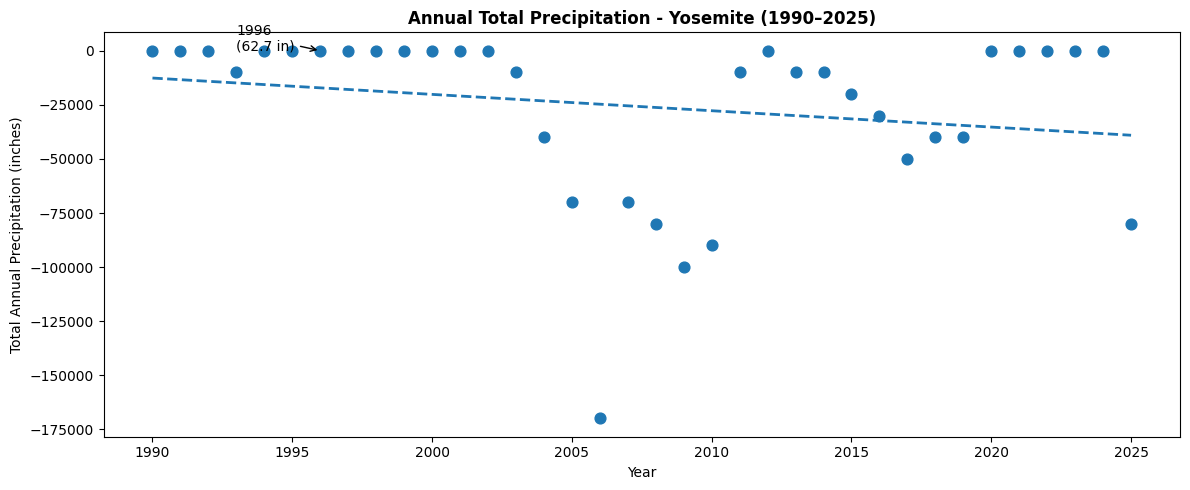

Overall trend: -755.805 inches per year
Wettest year: 1996 (62.7 inches)
Driest year: 2006 (-169953.1 inches)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

# load raw data
path = "https://raw.githubusercontent.com/COGS108/Group046_WI26/Ria/data/00-raw/raw_precipitation_data.csv"
df = pd.read_csv(path)

# filter Yosemite station
precip = df[df['STATION_NAME'].str.contains('YOSEMITE', na=False)].copy()

# correct date conversion
precip['Date'] = pd.to_datetime(precip['DATE'], format='%Y%m%d')

# rename precipitation column
precip.rename(columns={'PRCP': 'Precipitation'}, inplace=True)

# extract year after fixing date
precip['Year'] = precip['Date'].dt.year

# aggregate to annual totals
annual_total = (
    precip
    .groupby('Year')['Precipitation']
    .sum()
    .reset_index()
)

# fit linear trend line
z = np.polyfit(annual_total['Year'],
               annual_total['Precipitation'], 1)
p = np.poly1d(z)

# create figure
fig, ax = plt.subplots(figsize=(12, 5))

# scatter plot
ax.scatter(
    annual_total['Year'],
    annual_total['Precipitation'],
    s=60,
    zorder=3,
    label='Annual Total Precipitation'
)

# trend line
x_range = np.linspace(
    annual_total['Year'].min(),
    annual_total['Year'].max(),
    200
)

ax.plot(
    x_range,
    p(x_range),
    linestyle='--',
    linewidth=2,
    label=f'Trend (slope={z[0]:.2f} inches/year)'
)

# annotate wettest year
wettest = annual_total.loc[
    annual_total['Precipitation'].idxmax()
]

ax.annotate(
    f"{int(wettest['Year'])}\n({wettest['Precipitation']:.1f} in)",
    xy=(wettest['Year'], wettest['Precipitation']),
    xytext=(wettest['Year'] - 3,
            wettest['Precipitation'] + 5),
    arrowprops=dict(arrowstyle='->')
)

# labels & formatting
ax.set_xlabel('Year')
ax.set_ylabel('Total Annual Precipitation (inches)')
ax.set_title('Annual Total Precipitation - Yosemite (1990–2025)',
             fontweight='bold')

ax.xaxis.set_major_locator(ticker.MultipleLocator(5))

plt.tight_layout()
plt.show()

# print summary
driest = annual_total.loc[
    annual_total['Precipitation'].idxmin()
]

print(f"Overall trend: {z[0]:+.3f} inches per year")
print(f"Wettest year: {int(wettest['Year'])} "
      f"({wettest['Precipitation']:.1f} inches)")
print(f"Driest year: {int(driest['Year'])} "
      f"({driest['Precipitation']:.1f} inches)")

The trend line slope tells us the average annual change in total precipitation over the 35 year study period. A positive slope indicates that Yosemite has experienced a slight increase in annual precipitation from 1990 to 2025. Spike years, such as the wettest year in the dataset, possibly relate to extreme storm events or strong atmospheric river systems, whereas the driest year reflects periods of drought or low snowpack accumulation. These shifts in data, combined with the long-term trend, explains the importance of monitoring precipitation for park management. This is because variability in precipitation can affect water resources, snowpack levels, trail safety, and flood/landslide risk. Understanding these patterns are essential for anticipating climate impacts on both the park’s natural systems and visitor experiences.

## Ethics

### A. Data Collection
 - **A.1 Informed consent**: Our project utilizes secondary data from trailhead sensors and EPA monitors. The data is collected at an aggregate level with no Personally Identifiable Information (PII). We treat missing monitor days as genuinely missing rather than 'Good' air quality.

 - [X] **A.2 Collection bias**: We acknowledge that activity outside official park hours or uncharted areas of the park is not captured. We focus on consistent data sources and specify temporal scope to avoid confounding variables.
 - [X] **A.3 Limit PII exposure**: All data is anonymized aggregate counts. We limit the dataset to only variables necessary to address the research question.

 - **A.4 Downstream bias mitigation**: Results cannot be used to infer behavioral differences among specific groups of people.

### B. Data Storage
 - [ ] **B.1 Data security**: Data is stored on password-protected devices and a private GitHub repository accessible only by team members.
 - [ ] **B.2 Right to be forgotten**: Data is fully anonymized; no individual records exist to remove.
 - [ ] **B.3 Data retention plan**: Datasets will be deleted after the course project unless needed for academic purposes.

### C. Analysis
 - [ ] **C.1 Missing perspectives**: We cannot account for individual visitor motivations, health conditions, or socioeconomic constraints. We ground interpretations in established literature.
 - [ ] **C.2 Dataset bias**: Spatial mismatch between the Yosemite Village EPA monitor and high-elevation trailheads may not reflect localized smoke patterns. We mitigate this with temperature and precipitation control variables.
 - [ ] **C.3 Honest representation**: Results will be conveyed as associations, not causal relationships. All figures will have clearly labeled axes and 95% confidence intervals.
 - [ ] **C.4 Privacy in analysis**: Only aggregated daily-level summaries are reported.
 - [ ] **C.5 Auditability**: Full workflow is maintained in a GitHub repository with version control.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Trailhead counts may proxy for socioeconomic status. We will acknowledge that the average behavioral response may be skewed toward visitors with more autonomy to reschedule trips.
 - [X] **D.2 Fairness across groups**: AQI disproportionately impacts vulnerable groups. Stable attendance numbers do not imply all visitor groups are equally protected.
 - [X] **D.3 Metric selection**: Metrics are framed as indicators of recreational demand during environmental hazards, not holistic measures of trail importance.
 - [X] **D.4 Explainability**: Multiple linear regression coefficients and 95% confidence intervals will be reported to ensure interpretable results for stakeholders.
 - [X] **D.5 Communicate limitations**: Study is restricted to Yosemite, 1990–2023, and findings may not generalize to other parks. The model identifies associations, not causation.

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: We will audit predictions against actual sensor counts to detect concept drift over time.
 - [X] **E.2 Redress**: If outputs lead to societal harm or resource misallocation, we will review and correct the model.
 - [X] **E.3 Roll back**: Git version control allows rollback to any stable state if a prediction creates a problematic feedback cycle.
 - [X] **E.4 Unintended use**: We will clearly communicate that the model identifies associations rather than causal relationships to prevent misuse.


## Team Expectations

Katelyn Yap's Expectations: Respond to group chat messages within 10 hours. Let members know when they are going to be too busy (midterms etc).

Vy Nguyen's Expectations: Communications on Discord will be replied to during school and wake hours 9am, 201310pm. Communication on progress will be updated every week during our meeting (online or in-person).

Laird Fowle's Expectations: There will be weekly meetings that discuss deadlines/obligations to ensure everyone is up to date. Max response wait of 2 hours, especially on the day of a deadline.

Cindy Tao's Expectations: Everyone will complete assigned tasks on time and communicate ahead of the deadline if issues arise. Feedback and disagreements will be handled respectfully and constructively.

Ria Parikh's Expectations: There will be weekly check-ins on assigned tasks. Ensure to respond in a timely manner in the Discord chat. Address any absences or potential sickness/lateness prior to due dates.


## Project Timeline Proposal

| Date & Time        | Task |
|-------------------|------|
| 3/13, 11:00 PM    | Analysis: Finalize inferential or predictive models (e.g., Regression, ANOVA). Draft results, discussion, and conclusion sections of the final report. |
| 3/18, 11:00 PM    | Record Final Video summary for a non-technical audience. Turn in Final Report and Video; complete Group Project Surveys. |
